This code is based on the function detect_spikes for optogenetic excitation in CC to count spikes per sweep, display it and save spike count per sweep as csv 

In [1]:
import numpy as np 
import pyabf
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors 
import pyabf 
import seaborn as sns
import os
import pandas as pd
from ephys_functions import detect_peaks


For control recording of double_opto experiments:
blue light between 2-7 seconds, red light at 7s
counting spikes only in time window between 7-10s

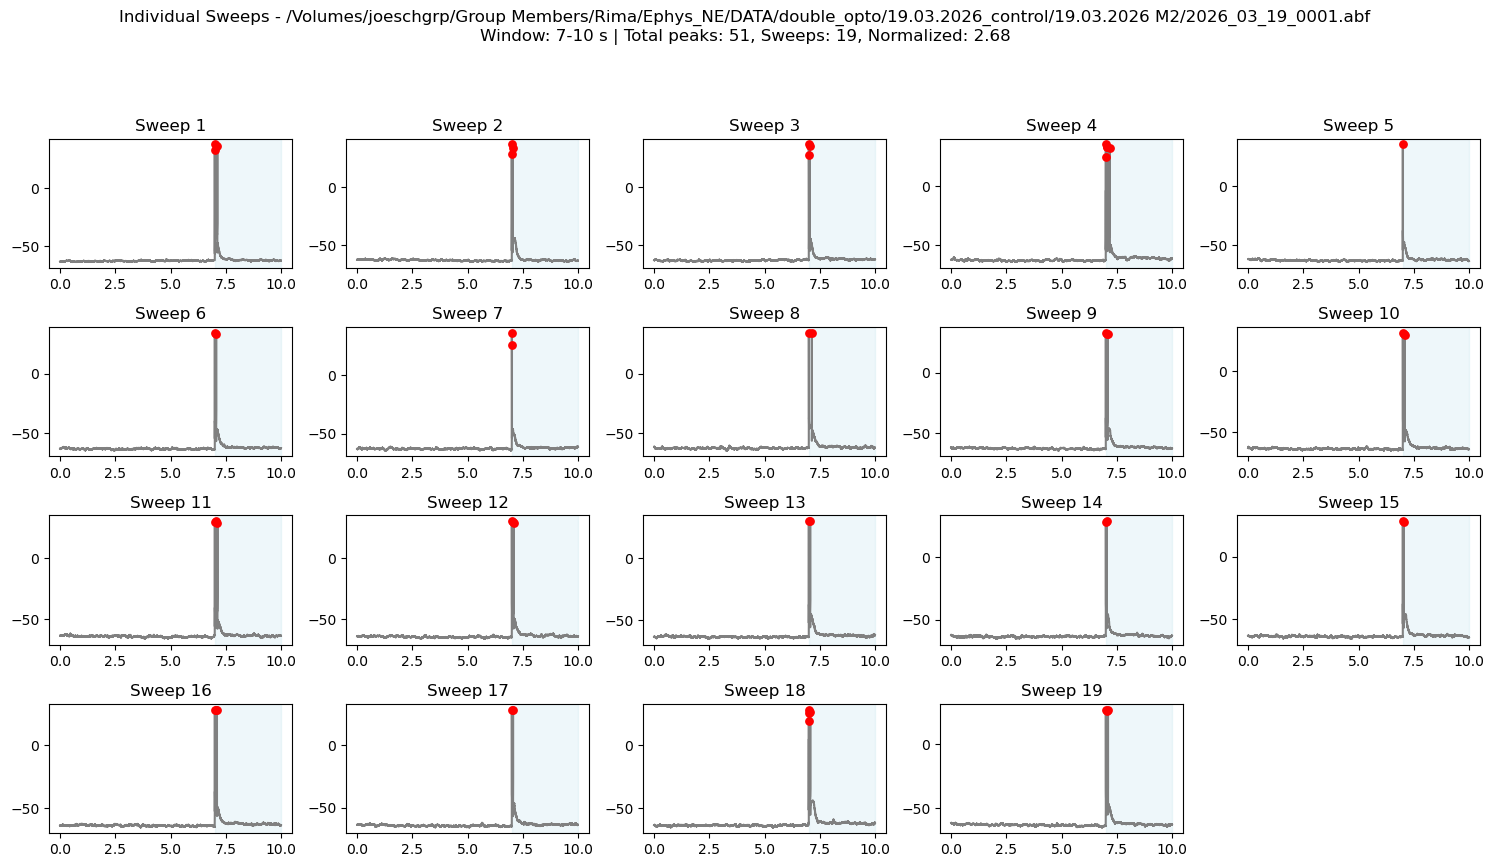

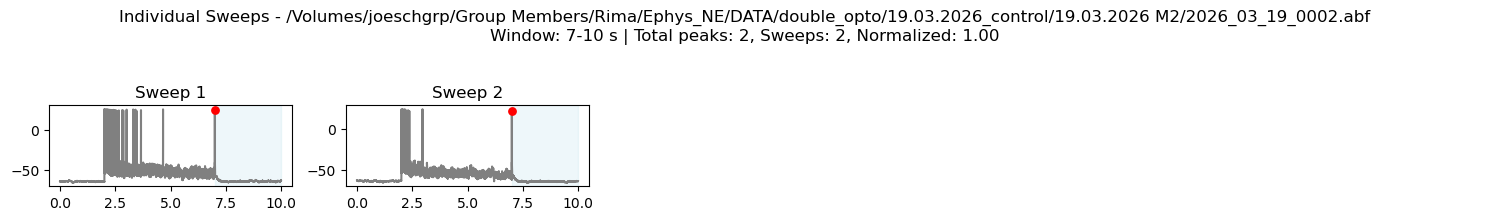

' df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"] )\ncsv_file_path = "/Users/rbondare/ephys_scripts/spikes_summary.csv"\ndf.to_csv(csv_file_path, index=False)\n\nprint(f"Results saved to {csv_file_path}")\ndf '

In [2]:
base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/19.03.2026_control"

# list of abf files for experiments 19.03.2026
abf_files = [
    os.path.join(base_dir, "19.03.2026 M2/2026_03_19_0001.abf"),
    os.path.join(base_dir, "19.03.2026 M2/2026_03_19_0002.abf")
]
def count_and_plot_peaks_per_sweep(
    abf_file,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    detection_window=(7, 10),
):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)

    # Layout similar to your previous output
    n_cols = 5
    n_rows = int(np.ceil(n_sweeps / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.0 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    peak_counts = []
    total_peaks = 0

    for i, sweep in enumerate(abf.sweepList):
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        window_mask = (x >= detection_window[0]) & (x <= detection_window[1])
        x_window = x[window_mask]
        y_window = y[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
        else:
            peaks = np.array([], dtype=int)

        n_peaks = len(peaks)
        peak_counts.append(n_peaks)
        total_peaks += n_peaks

        ax = axes[i]
        ax.plot(x, y, color="gray", linewidth=1.5)
        ax.axvspan(detection_window[0], detection_window[1], color="lightblue", alpha=0.2)
        if n_peaks > 0:
            ax.scatter(x[peaks], y[peaks], color="red", s=28, zorder=3)

        ax.set_title(f"Sweep {sweep + 1}")

    # Hide unused axes
    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")

    norm_spikes = total_peaks / n_sweeps if n_sweeps > 0 else 0

    plt.suptitle(
        f"Individual Sweeps - {abf_file}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s | "
        f"Total peaks: {total_peaks}, Sweeps: {n_sweeps}, Normalized: {norm_spikes:.2f}",
        fontsize=12
    )
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    return abf_file, norm_spikes, peak_counts

# Process each file, visualize peaks per sweep, and collect summary
results = []
for abf_file in abf_files:
    file_path, norm_spikes, peak_counts = count_and_plot_peaks_per_sweep(
        abf_file, height_threshold=5, detection_window=(7, 10)
    )
    results.append([file_path, f"{norm_spikes:.2f}", peak_counts])

df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"])

# Save summary to CSV
""" df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"] )
csv_file_path = "/Users/rbondare/ephys_scripts/spikes_summary.csv"
df.to_csv(csv_file_path, index=False)

print(f"Results saved to {csv_file_path}")
df """

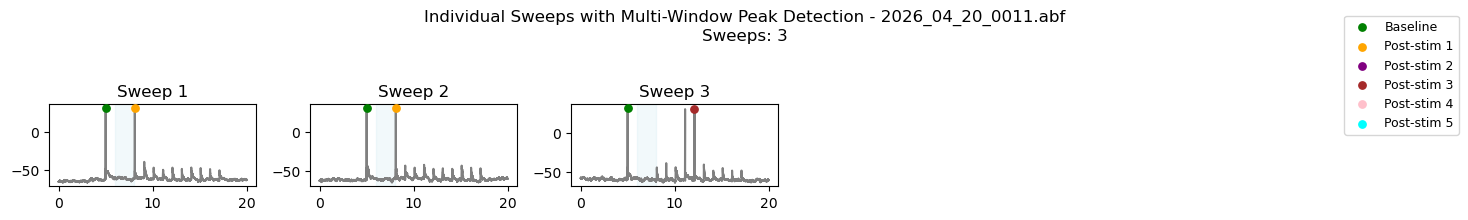

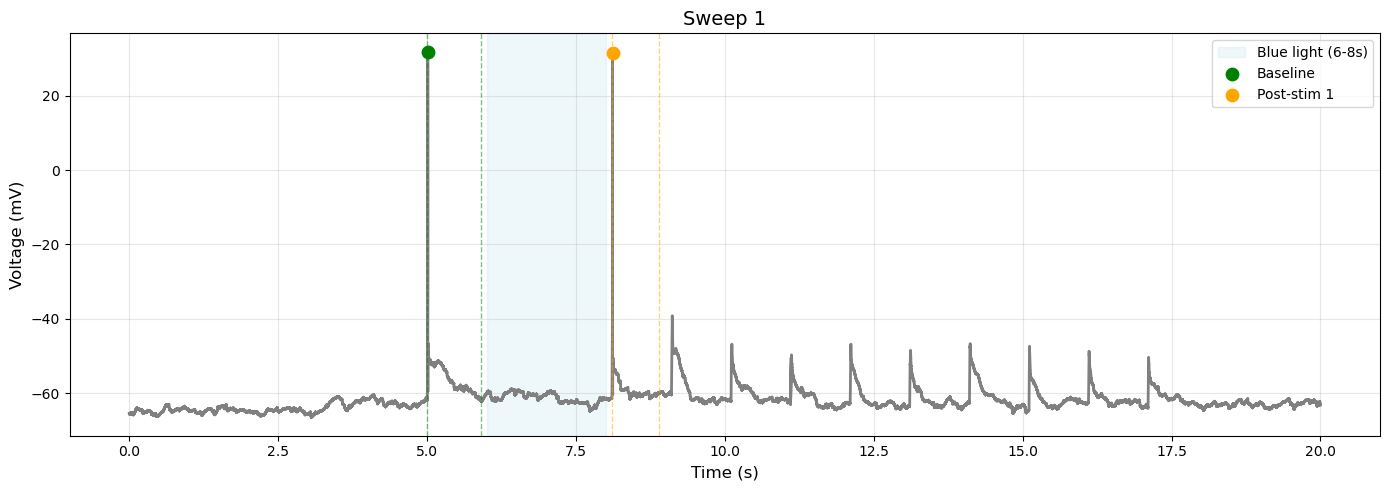

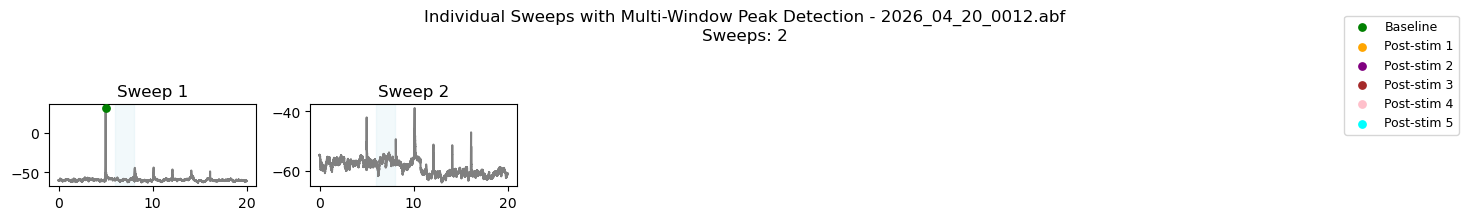

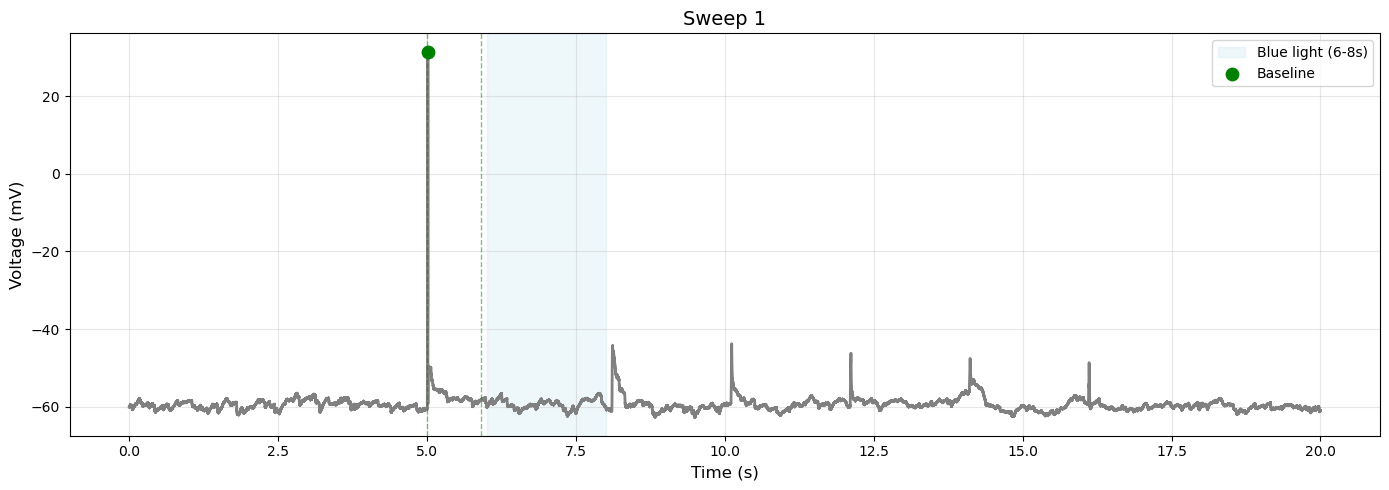

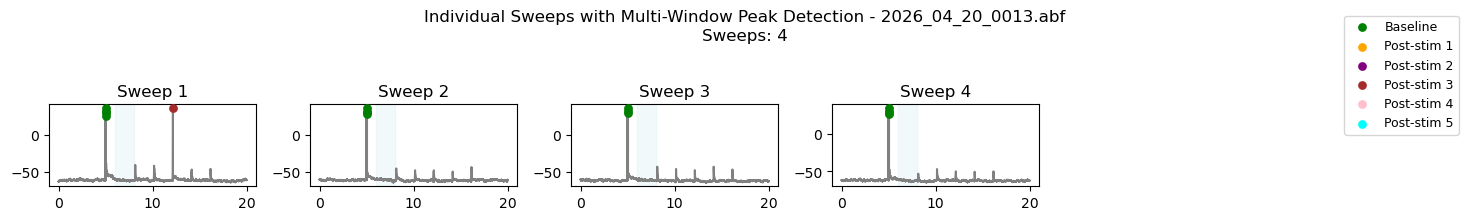

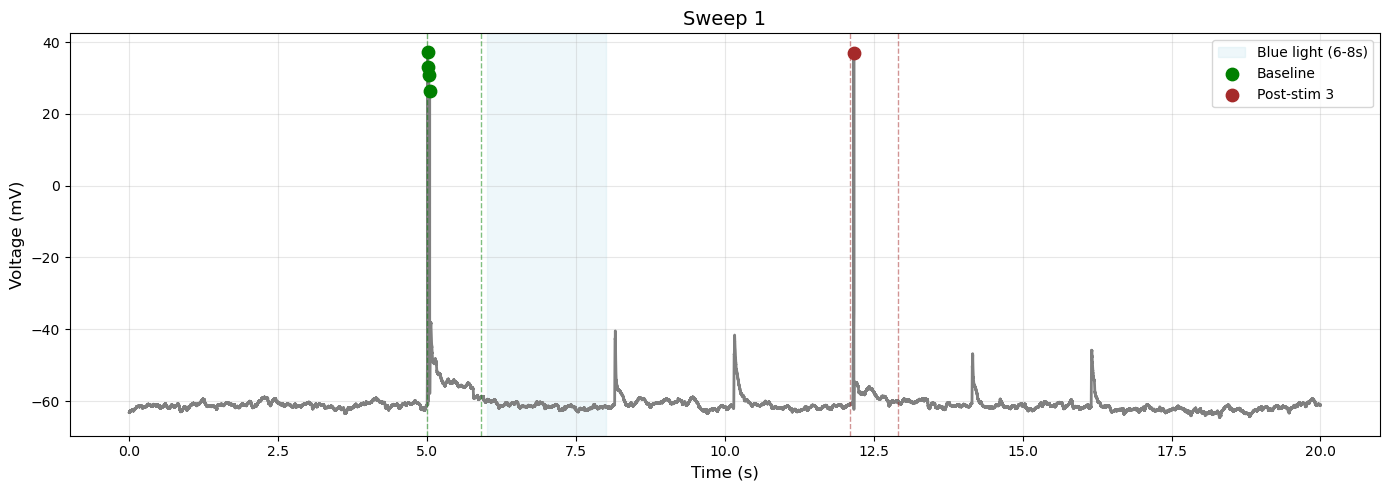

,File,Baseline avg,Baseline sweep1,Post-stim 1 avg,Post-stim 1 sweep1,Post-stim 2 avg,Post-stim 2 sweep1,Post-stim 3 avg,Post-stim 3 sweep1,Post-stim 4 avg,Post-stim 4 sweep1,Post-stim 5 avg,Post-stim 5 sweep1
0,2026_04_20_0011.abf,1.00,1,0.67,1,0.00,0,0.33,0,0.00,0,0.00,0
1,2026_04_20_0012.abf,0.50,1,0.00,0,0.00,0,0.00,0,0.00,0,0.00,0
2,2026_04_20_0013.abf,3.75,4,0.00,0,0.00,0,0.25,1,0.00,0,0.00,0


In [3]:
base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/20.04.2026"

# list of abf files for experiments 19.03.2026
abf_files = [
    os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0011.abf"),
    os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0012.abf"),
    os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0013.abf")
]

# Define time windows for each stimulus phase
# Format: (start, end, label, color)
stimulus_windows = [
    (5.0, 5.9, "Baseline", "green"),
    (8.1, 8.9, "Post-stim 1", "orange"),
    (10.1, 10.9, "Post-stim 2", "purple"),
    (12.1, 12.9, "Post-stim 3", "brown"),
    (14.1, 14.9, "Post-stim 4", "pink"),
    (16.1, 16.9, "Post-stim 5", "cyan"),
]

def count_and_plot_peaks_multi_window(
    abf_file,
    stimulus_windows,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    sweep_to_zoom=0,
    show_grid=True,
    ):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)

    # Layout similar to your previous output
    n_cols = 5
    n_rows = int(np.ceil(n_sweeps / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.0 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False
    )
    axes = np.atleast_1d(axes).ravel()

    # Dictionary to store peak counts per window per sweep
    peak_counts_by_window = {label: [] for _, _, label, _ in stimulus_windows}
    total_peaks_by_window = {label: 0 for _, _, label, _ in stimulus_windows}

    for i, sweep in enumerate(abf.sweepList):
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        ax = axes[i]
        ax.plot(x, y, color="gray", linewidth=1.5)

        # Highlight blue light window (6-8s)
        ax.axvspan(6.0, 8.0, color="lightblue", alpha=0.15, label="Blue light")

        # Process each stimulus window
        for start, end, label, color in stimulus_windows:
            window_mask = (x >= start) & (x <= end)
            x_window = x[window_mask]
            y_window = y[window_mask]

            if y_window.size > 0:
                peaks_window, _ = detect_peaks(
                    y_window,
                    height_threshold=height_threshold,
                    prominence_min=prominence_min,
                    distance_min=distance_min,
                )
                peaks = np.where(window_mask)[0][peaks_window]
            else:
                peaks = np.array([], dtype=int)

            n_peaks = len(peaks)
            peak_counts_by_window[label].append(n_peaks)
            total_peaks_by_window[label] += n_peaks

            # Plot peaks with window-specific color
            if n_peaks > 0:
                ax.scatter(x[peaks], y[peaks], color=color, s=28, zorder=3)

        ax.set_title(f"Sweep {sweep + 1}")

    # Hide unused axes
    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")

    # Create legend with window labels and colors
    legend_elements = [
        plt.scatter([], [], color=color, s=28, label=label)
        for _, _, label, color in stimulus_windows
    ]
    fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=9)

    plt.suptitle(
        f"Individual Sweeps with Multi-Window Peak Detection - {os.path.basename(abf_file)}\n"
        f"Sweeps: {n_sweeps}",
        fontsize=12
    )
    plt.tight_layout(rect=[0, 0, 0.88, 0.93])
    plt.show()

    # Create large detailed plot of sweep `sweep_to_zoom` (default 0)
    zoom_idx = max(0, min(sweep_to_zoom, n_sweeps-1))
    fig_zoom, ax_zoom = plt.subplots(figsize=(14, 5))

    abf.setSweep(zoom_idx)
    x_sweep1 = abf.sweepX
    y_sweep1 = abf.sweepY

    ax_zoom.plot(x_sweep1, y_sweep1, color="gray", linewidth=2.0)

    # Highlight blue light window (6-8s)
    ax_zoom.axvspan(6.0, 8.0, color="lightblue", alpha=0.2, label="Blue light (6-8s)")

    # Process and plot peaks for each stimulus window
    for start, end, label, color in stimulus_windows:
        window_mask = (x_sweep1 >= start) & (x_sweep1 <= end)
        x_window = x_sweep1[window_mask]
        y_window = y_sweep1[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
        else:
            peaks = np.array([], dtype=int)

        if len(peaks) > 0:
            ax_zoom.scatter(x_sweep1[peaks], y_sweep1[peaks], color=color, s=80, zorder=3, label=label)
            # Add vertical lines to highlight stimulus windows
            ax_zoom.axvline(start, color=color, linestyle="--", alpha=0.5, linewidth=1)
            ax_zoom.axvline(end, color=color, linestyle="--", alpha=0.5, linewidth=1)

    ax_zoom.set_xlabel("Time (s)", fontsize=12)
    ax_zoom.set_ylabel("Voltage (mV)", fontsize=12)
    ax_zoom.set_title(f"Sweep {zoom_idx+1}", fontsize=14)
    ax_zoom.legend(loc="upper right", fontsize=10)
    if show_grid:
        ax_zoom.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return abf_file, peak_counts_by_window, total_peaks_by_window

# Process each file
results_multi_window = []
for abf_file in abf_files:
    file_path, peak_counts_by_window, total_peaks_by_window = count_and_plot_peaks_multi_window(
        abf_file, stimulus_windows, height_threshold=5, sweep_to_zoom=0
    )
    results_multi_window.append({
        "file": os.path.basename(abf_file),
        "peak_counts_by_window": peak_counts_by_window,
        "total_peaks_by_window": total_peaks_by_window,
    })

# Create summary table: normalized peak count per stimulus window + sweep-1 counts
summary_data = []
for result in results_multi_window:
    row = {"File": result["file"]}
    # number of sweeps for this file (derived from lists)
    if len(result["peak_counts_by_window"])>0:
        n_sweeps = len(next(iter(result["peak_counts_by_window"].values())))
    else:
        n_sweeps = 0
    for _, _, label, _ in stimulus_windows:
        total = result["total_peaks_by_window"].get(label, 0)
        avg = total / n_sweeps if n_sweeps>0 else 0
        # sweep1 (first sweep) count for this label
        sweep1_count = result["peak_counts_by_window"].get(label, [0])[0] if n_sweeps>0 else 0
        row[f"{label} avg"] = f"{avg:.2f}"
        row[f"{label} sweep1"] = int(sweep1_count)
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
df_summary

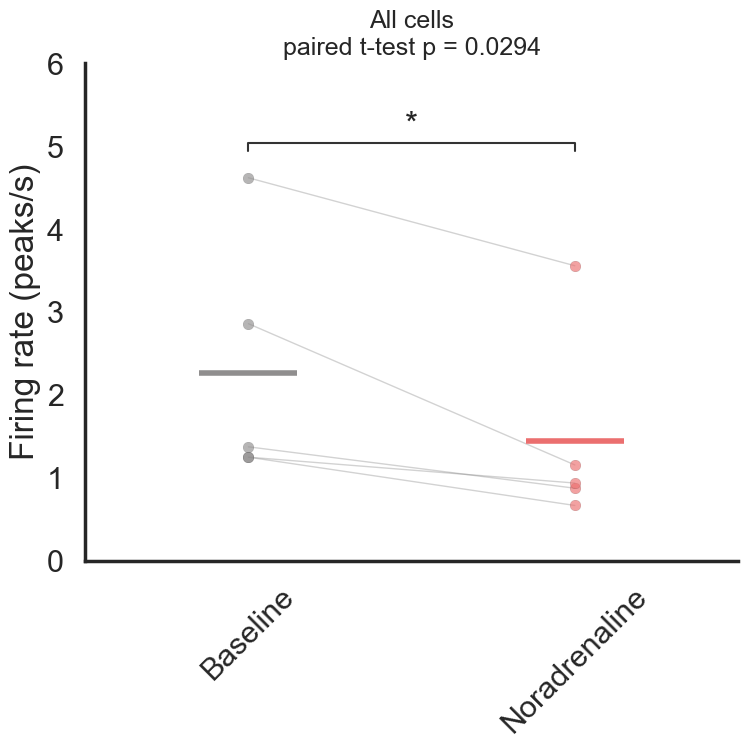

,Cell_ID,Baseline_Counts,NA_Counts,Baseline_FR,NA_FR,Delta_FR,Percent_Change,Fold_Change
0,1,1.00,0.533333,1.2500,0.666667,-0.583333,-46.666667,0.533333
1,2,2.29,0.925000,2.8625,1.156250,-1.706250,-59.606987,0.403930
2,3,3.70,2.850000,4.6250,3.562500,-1.062500,-22.972973,0.770270
3,4,1.10,0.700000,1.3750,0.875000,-0.500000,-36.363636,0.636364
4,5,1.00,0.750000,1.2500,0.937500,-0.312500,-25.000000,0.750000


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statannotations.Annotator import Annotator

sns.set_context("poster")
sns.set_style("white")

# =============================================================================
# USER SETTINGS 
# =============================================================================

results_table_path = "/Users/rbondare/ephys/results/double_opto_database.xlsx"
sheet_name = "Noradrenaline"

id_col = "ID"
# we'll extract post_stim_3_avg for both baseline and NA conditions
poststim_col = "post_stim_3_avg"

# time window (s) over which counts were measured
time_window = 0.8

baseline_label = "Baseline"
na_label = "Noradrenaline"

y_label = "Firing rate (peaks/s)"


# =============================================================================
# DATA PREPARATION
# =============================================================================

def prepare_paired_dataset_from_condition(df, id_col, condition_col, value_col):
    # Select rows for baseline and noradrenaline conditions and take mean per ID
    df = df.copy()
    if condition_col not in df.columns:
        raise KeyError(f"Missing condition column: {condition_col}\nAvailable: {list(df.columns)}")

    # normalize condition strings for matching
    cond = df[condition_col].astype(str).str.strip().str.lower()

    baseline_rows = df[cond == 'baseline'][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'Baseline_Counts'})
    na_rows = df[cond.str.contains('noradrenaline')][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'NA_Counts'})

    # coerce numeric and groupby mean in case of duplicates
    baseline_rows['Baseline_Counts'] = pd.to_numeric(baseline_rows['Baseline_Counts'], errors='coerce')
    na_rows['NA_Counts'] = pd.to_numeric(na_rows['NA_Counts'], errors='coerce')

    baseline_agg = baseline_rows.groupby('Cell_ID', as_index=False)['Baseline_Counts'].mean()
    na_agg = na_rows.groupby('Cell_ID', as_index=False)['NA_Counts'].mean()

    # merge on Cell_ID — keep only cells that have both baseline and NA
    paired = pd.merge(baseline_agg, na_agg, on='Cell_ID', how='inner')

    # compute firing rates (peaks per second) from counts-per-sweep
    paired['Baseline_FR'] = paired['Baseline_Counts'] / time_window
    paired['NA_FR'] = paired['NA_Counts'] / time_window

    paired['Delta_FR'] = paired['NA_FR'] - paired['Baseline_FR']
    paired['Percent_Change'] = np.where(
        paired['Baseline_FR'] != 0,
        paired['Delta_FR'] / paired['Baseline_FR'] * 100,
        np.nan,
    )
    paired['Fold_Change'] = np.where(
        paired['Baseline_FR'] != 0,
        paired['NA_FR'] / paired['Baseline_FR'],
        np.nan,
    )

    return paired


# =============================================================================
# STATISTICS
# =============================================================================

def compute_paired_stats(paired_df):
    paired_t = stats.ttest_rel(paired_df["Baseline_FR"], paired_df["NA_FR"], nan_policy="omit")

    try:
        wilcoxon_result = stats.wilcoxon(paired_df["Baseline_FR"], paired_df["NA_FR"])
        wilcoxon_p = wilcoxon_result.pvalue
    except ValueError:
        wilcoxon_p = np.nan

    return paired_t.pvalue, wilcoxon_p


# =============================================================================
# MAIN PAIRED PLOT 
# =============================================================================

def paired_plot(ax, data, title):
    conditions = [baseline_label, na_label]
    colors_fill = ["lightgrey", "lightcoral"]
    colors_points = ["#908E8E", "#EB6F6F"]

    box_data = [data["Baseline_FR"].values, data["NA_FR"].values]

    ax.boxplot(
        box_data,
        positions=range(2),
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="none"),
        boxprops=dict(facecolor="none", edgecolor="none"),
        whiskerprops=dict(color="none"),
        capprops=dict(color="none"),
    )

    for i, patch in enumerate(ax.artists):
        patch.set_facecolor(colors_fill[i])
        patch.set_alpha(0.9)

    for _, row in data.iterrows():
        y = [row["Baseline_FR"], row["NA_FR"]]
        x = [0, 1]

        ax.plot(x, y, color="gray", alpha=0.35, linewidth=1)

        for j, yi in enumerate(y):
            ax.scatter(
                x[j], yi,
                color=colors_points[j],
                alpha=0.65,
                s=60,
                edgecolors="black",
                linewidths=0.1,
                zorder=3,
            )

    for i, col in enumerate(["Baseline_FR", "NA_FR"]):
        mean_y = data[col].mean()
        ax.hlines(mean_y, i - 0.15, i + 0.15, color=colors_points[i], linewidth=4)

    plot_long = pd.DataFrame({
        "value": np.concatenate([data["Baseline_FR"], data["NA_FR"]]),
        "group": [baseline_label] * len(data) + [na_label] * len(data),
    })

    annotator = Annotator(ax, [(baseline_label, na_label)], data=plot_long, x="group", y="value")
    annotator.configure(test="t-test_paired", text_format="star", loc="outside", verbose=False)
    annotator.apply_and_annotate()

    max_y = max(data["Baseline_FR"].max(), data["NA_FR"].max())

    ax.set_xticks([0, 1])
    ax.set_xticklabels(conditions, rotation=45)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, max_y * 1.3 if max_y > 0 else 1)
    ax.set_title(title, fontsize=18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# =============================================================================
# RUN ANALYSIS
# =============================================================================

if not os.path.exists(results_table_path):
    raise FileNotFoundError(results_table_path)

source_df = pd.read_excel(results_table_path, sheet_name=sheet_name, header=1)

paired_df = prepare_paired_dataset_from_condition(source_df, id_col=id_col, condition_col='condition', value_col=poststim_col)

paired_p, wilcoxon_p = compute_paired_stats(paired_df)

fig, ax = plt.subplots(figsize=(8, 8))
paired_plot(ax, paired_df, f"All cells\npaired t-test p = {paired_p:.3g}")
plt.tight_layout()
plt.show()

# show both counts and firing rates for verification
pd.options.display.max_columns = None
display(paired_df.head())
